# Structural VAR: Replication of Stock & Watson (2001)

**Reference:** Stock, J.H. and Watson, M.W. (2001). "Vector Autoregressions." *Journal of Economic Perspectives*, 15(4), 101–115.

We estimate a trivariate SVAR with:
- **Inflation**: GDP deflator inflation (annualized quarterly % change)
- **Unemployment**: Unemployment rate
- **Fed Funds**: Federal Funds Rate

Sample: 1960Q1 – 2019Q4

Two Cholesky orderings are compared:
1. **SW ordering**: Inflation → Unemployment → Fed Funds (monetary policy shock last)
2. **Alternative ordering**: Inflation → Fed Funds → Unemployment (Fed Funds second)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from fredapi import Fred
from statsmodels.tsa.api import VAR
from scipy.linalg import cholesky
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})

## 1. Download data from FRED

- `GDPDEF` — GDP Implicit Price Deflator (index, quarterly, seasonally adjusted)
- `UNRATE` — Civilian Unemployment Rate (monthly → quarterly average)
- `FEDFUNDS` — Effective Federal Funds Rate (monthly → quarterly average)

Inflation is computed as the annualized quarter-on-quarter log-difference of the GDP deflator:
$$\pi_t = 400 \times \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [31]:
# ── FRED API key ─────────────────────────────────────────────────────────────
# Get a free key at https://fred.stlouisfed.org/docs/api/api_key.html
# and paste it below, or set the environment variable FRED_API_KEY
import os
API_KEY = os.environ.get('FRED_API_KEY', 'tu_api_key_acá')
fred = Fred(api_key=API_KEY)

START = '1959-10-01'   # one extra quarter for the inflation lag
END   = '2019-12-31'

# GDP Deflator (quarterly)
gdpdef   = fred.get_series('GDPDEF',   observation_start=START, observation_end=END)

# Unemployment rate (monthly → quarterly average)
unrate_m = fred.get_series('UNRATE',   observation_start=START, observation_end=END)
unrate   = unrate_m.resample('QS').mean()

# Fed Funds rate (monthly → quarterly average)
fedfunds_m = fred.get_series('FEDFUNDS', observation_start=START, observation_end=END)
fedfunds   = fedfunds_m.resample('QS').mean()

# Annualized quarterly inflation from GDP deflator
inflation = 400 * np.log(gdpdef / gdpdef.shift(1))

# Align to common quarterly index, trim to 1960Q1–2019Q4
data = pd.DataFrame({
    'inflation':  inflation,
    'unrate':     unrate,
    'fedfunds':   fedfunds
}).dropna()

data = data.loc['1960-01-01':'2019-10-01']

def fmt_quarter(ts):
    q = (ts.month - 1) // 3 + 1
    return f"{ts.year}Q{q}"

print(f"Sample: {fmt_quarter(data.index[0])} – {fmt_quarter(data.index[-1])}")
print(f"Observations: {len(data)}")
data.tail()



Sample: 1960Q1 – 2019Q4
Observations: 240


,inflation,unrate,fedfunds
2018-10-01,1.719880,3.833333,2.220000
2019-01-01,1.197983,3.866667,2.403333
2019-04-01,2.061880,3.633333,2.396667
2019-07-01,1.268902,3.600000,2.190000
2019-10-01,1.241928,3.600000,1.643333


## 2. Plot the data

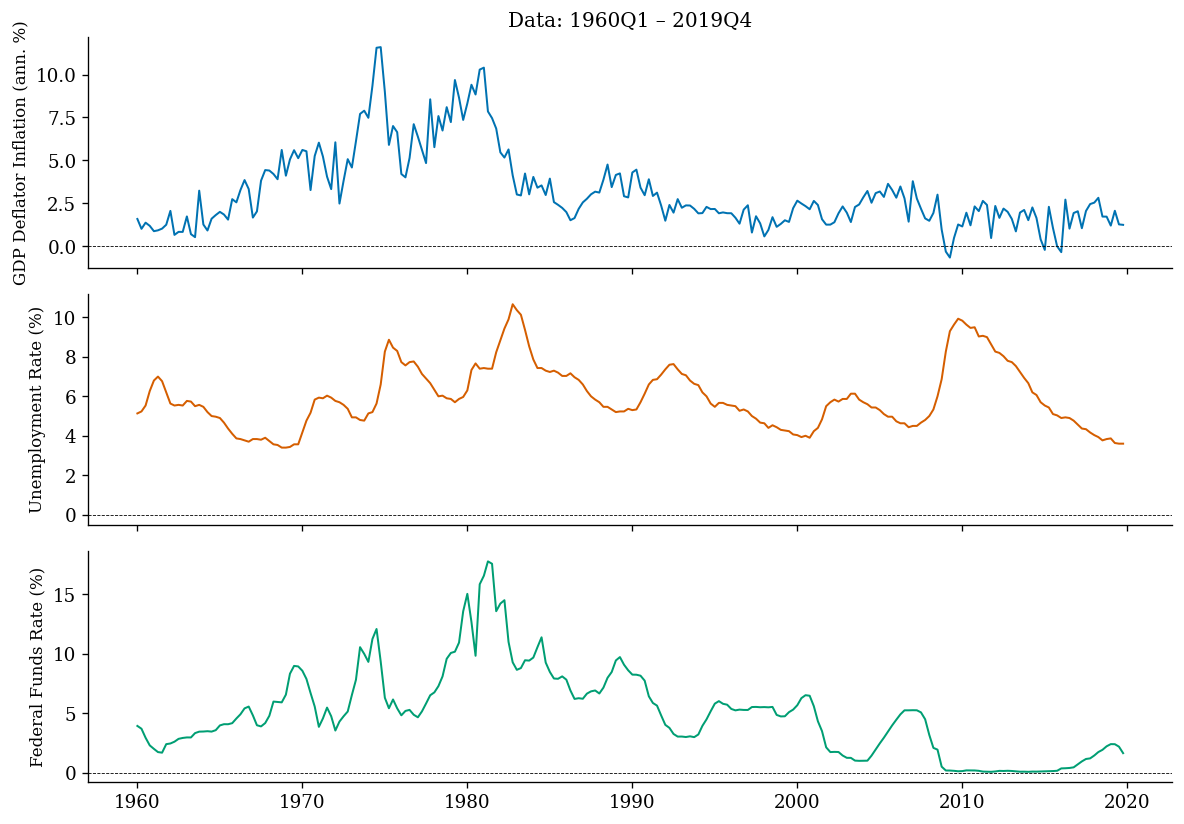

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
series   = ['inflation', 'unrate', 'fedfunds']
labels   = ['GDP Deflator Inflation (ann. %)', 'Unemployment Rate (%)', 'Federal Funds Rate (%)']
colors   = ['#0072B2', '#D55E00', '#009E73']

for ax, var, lab, col in zip(axes, series, labels, colors):
    ax.plot(data.index, data[var], color=col, lw=1.2)
    ax.set_ylabel(lab, fontsize=10)
    ax.axhline(0, color='k', lw=0.5, ls='--')

axes[0].set_title('Data: 1960Q1 – 2019Q4', fontsize=12)
axes[-1].set_xlabel('')
fig.tight_layout()
fig.savefig('fig1_stock_watson.pdf', bbox_inches='tight')
plt.show()


## 3. Estimate the reduced-form VAR

Lag order selection via AIC/BIC (Stock & Watson use 4 lags).

In [8]:
# SW ordering: inflation, unrate, fedfunds
Y_sw  = data[['inflation', 'unrate', 'fedfunds']].values
names_sw = ['Inflation', 'Unemployment', 'Fed Funds']

model_sw = VAR(Y_sw)

# Lag selection
lag_sel = model_sw.select_order(maxlags=8)
print(lag_sel.summary())

# Stock & Watson use 4 lags
NLAGS = 4
res_sw = model_sw.fit(NLAGS)
print(res_sw.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       4.561       4.605       95.65       4.579
1      -2.817      -2.639     0.05976      -2.746
2      -3.443     -3.131*     0.03198      -3.317
3      -3.528      -3.083     0.02936     -3.348*
4      -3.526      -2.947     0.02943      -3.292
5      -3.519      -2.806     0.02964      -3.232
6      -3.560      -2.714     0.02846      -3.219
7      -3.551      -2.570     0.02876      -3.155
8     -3.611*      -2.497    0.02708*      -3.162
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 11, Jun, 2026
Time:                     16:20:29
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -2.98443
Nobs:                     236.000    

## 4. SVAR – Cholesky identification

### Helper functions

In [10]:
def cholesky_irf(var_result, shock_pos, n_ahead=20):
    """
    Compute impulse responses to a one-standard-deviation Cholesky shock.
    
    Parameters
    ----------
    var_result : VARResults
    shock_pos  : int  — position of the shock variable (0-indexed)
    n_ahead    : int  — number of periods ahead
    
    Returns
    -------
    irf : ndarray, shape (n_ahead+1, n_vars)
        Response of each variable to the shock at shock_pos.
    """
    Sigma = var_result.sigma_u          # reduced-form residual covariance
    P     = cholesky(Sigma, lower=True) # lower-triangular Cholesky factor
    
    # Structural shock: column shock_pos of P (one-std shock)
    e = P[:, shock_pos]
    
    # Companion matrix IRF
    ma_reps = var_result.irf(n_ahead).irfs  # shape (n_ahead+1, n, n)
    # ma_reps[h, i, j] = response of var i to reduced-form shock j at horizon h
    # Structural response = ma_reps @ e
    irf = np.array([ma_reps[h] @ e for h in range(n_ahead + 1)])
    return irf


def bootstrap_irf_bands(Y, nlags, shock_pos, n_ahead=20,
                         n_boot=500, ci=0.68, seed=42):
    """
    Bootstrap confidence bands for Cholesky IRFs.
    Uses residual bootstrap (Runkle 1987).
    
    Returns
    -------
    irf_median : (n_ahead+1, n_vars)
    irf_lo     : (n_ahead+1, n_vars)
    irf_hi     : (n_ahead+1, n_vars)
    """
    rng  = np.random.default_rng(seed)
    nobs = len(Y)
    n    = Y.shape[1]
    
    # Fit baseline
    base = VAR(Y).fit(nlags)
    resid = base.resid           # (T - nlags, n)
    T_eff = resid.shape[0]
    
    # Coefficients and intercept
    # base.params: shape (k, n), rows = [const, lag1_var1, ..., lagp_varn]
    
    boot_irfs = np.zeros((n_boot, n_ahead + 1, n))
    
    for b in range(n_boot):
        # Resample residuals
        idx       = rng.integers(0, T_eff, size=T_eff)
        resid_b   = resid[idx]
        
        # Reconstruct bootstrap series
        Y_b = np.zeros((nobs, n))
        Y_b[:nlags] = Y[:nlags]   # fix initial conditions
        
        coefs  = base.coefs        # (nlags, n, n)
        intercept = base.intercept # (n,)
        
        for t in range(nlags, nobs):
            val = intercept.copy()
            for lag in range(nlags):
                val += coefs[lag] @ Y_b[t - lag - 1]
            val += resid_b[t - nlags]
            Y_b[t] = val
        
        # Fit VAR on bootstrap sample
        try:
            res_b = VAR(Y_b).fit(nlags)
            boot_irfs[b] = cholesky_irf(res_b, shock_pos, n_ahead)
        except Exception:
            boot_irfs[b] = np.nan
    
    alpha = (1 - ci) / 2
    irf_lo     = np.nanpercentile(boot_irfs, 100 * alpha,       axis=0)
    irf_median = np.nanpercentile(boot_irfs, 50,                axis=0)
    irf_hi     = np.nanpercentile(boot_irfs, 100 * (1 - alpha), axis=0)
    
    return irf_median, irf_lo, irf_hi


def plot_irf(irf_point, irf_lo, irf_hi, var_names, shock_name,
             n_ahead=20, title='', color='#0072B2'):
    """
    Plot impulse responses with bootstrap confidence bands.
    """
    n_vars  = len(var_names)
    periods = np.arange(n_ahead + 1)
    
    fig, axes = plt.subplots(1, n_vars, figsize=(4 * n_vars, 3.5))
    
    for i, (ax, name) in enumerate(zip(axes, var_names)):
        ax.fill_between(periods, irf_lo[:, i], irf_hi[:, i],
                        alpha=0.25, color=color, label='68% CI')
        ax.plot(periods, irf_point[:, i], color=color, lw=1.8, label='Point estimate')
        ax.axhline(0, color='k', lw=0.6, ls='--')
        ax.set_title(f'Response of {name}', fontsize=11)
        ax.set_xlabel('Quarters')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if i == 0:
            ax.set_ylabel('Percentage points')
    
    axes[-1].legend(fontsize=9, frameon=False)
    fig.suptitle(title, fontsize=12, y=1.02)
    fig.tight_layout()
    return fig

print('Helper functions defined.')

Helper functions defined.


## 5. Ordering 1: Stock & Watson (Inflation → Unemployment → Fed Funds)

The Cholesky ordering implies:
- Inflation does not respond contemporaneously to unemployment or monetary policy shocks.
- Unemployment does not respond contemporaneously to monetary policy shocks.
- The Fed Funds rate can respond contemporaneously to all variables.

We identify the **monetary policy shock** as the shock to the Fed Funds rate (position 2, third variable).

In [12]:
N_AHEAD = 20
N_BOOT  = 500

# Point estimate IRF
irf_sw = cholesky_irf(res_sw, shock_pos=2, n_ahead=N_AHEAD)

print('Computing bootstrap bands for SW ordering (this may take ~1 minute)...')
irf_med_sw, irf_lo_sw, irf_hi_sw = bootstrap_irf_bands(
    Y_sw, nlags=NLAGS, shock_pos=2,
    n_ahead=N_AHEAD, n_boot=N_BOOT
)
print('Done.')

Computing bootstrap bands for SW ordering (this may take ~1 minute)...
Done.


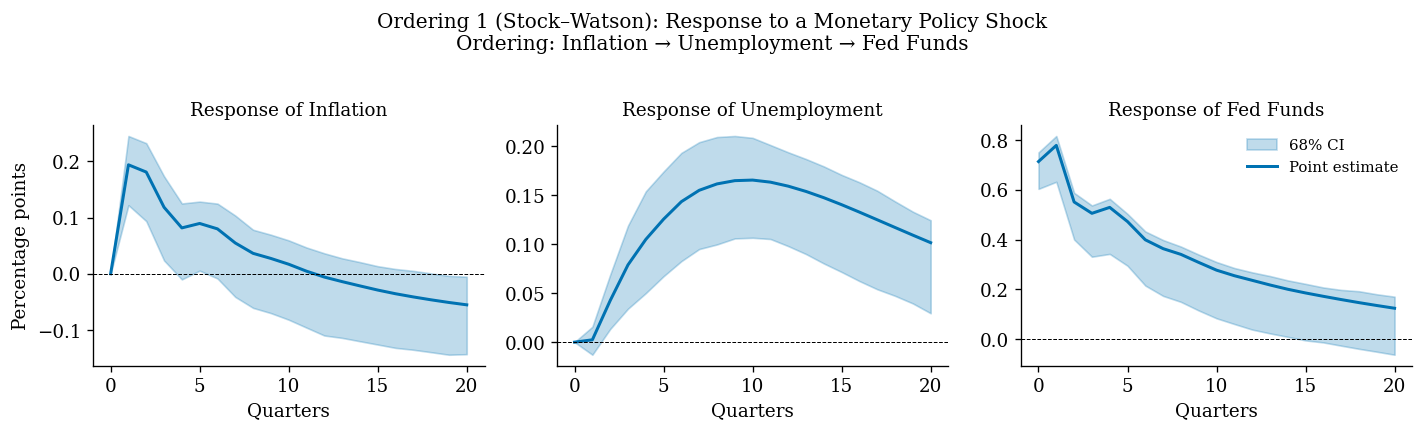

In [13]:
fig = plot_irf(
    irf_sw, irf_lo_sw, irf_hi_sw,
    var_names=names_sw,
    shock_name='Fed Funds',
    n_ahead=N_AHEAD,
    title='Ordering 1 (Stock–Watson): Response to a Monetary Policy Shock\n'
          'Ordering: Inflation → Unemployment → Fed Funds',
    color='#0072B2'
)
fig.savefig('fig2_irf_sw_ordering.pdf', bbox_inches='tight')
plt.show()


## 6. Ordering 2: Alternative (Unemployment → Fed Funds → Inflation)

Now Fed Funds is ordered second: it can respond contemporaneously to unemployment but not to inflation. Inflation is ordered last and responds contemporaneously to all shocks.

We identify the **monetary policy shock** as the shock to the Fed Funds rate (position 1, second variable).

In [15]:
# Alternative ordering: inflation, fedfunds,unrate 
Y_alt     = data[['inflation', 'fedfunds', 'unrate']].values
names_alt = ['Inflation', 'Fed Funds', 'Unemployment']

res_alt = VAR(Y_alt).fit(NLAGS)

# Point estimate: shock to position 1 (Fed Funds)
irf_alt = cholesky_irf(res_alt, shock_pos=1, n_ahead=N_AHEAD)

print('Computing bootstrap bands for alternative ordering...')
irf_med_alt, irf_lo_alt, irf_hi_alt = bootstrap_irf_bands(
    Y_alt, nlags=NLAGS, shock_pos=1,
    n_ahead=N_AHEAD, n_boot=N_BOOT
)
print('Done.')

Computing bootstrap bands for alternative ordering...
Done.


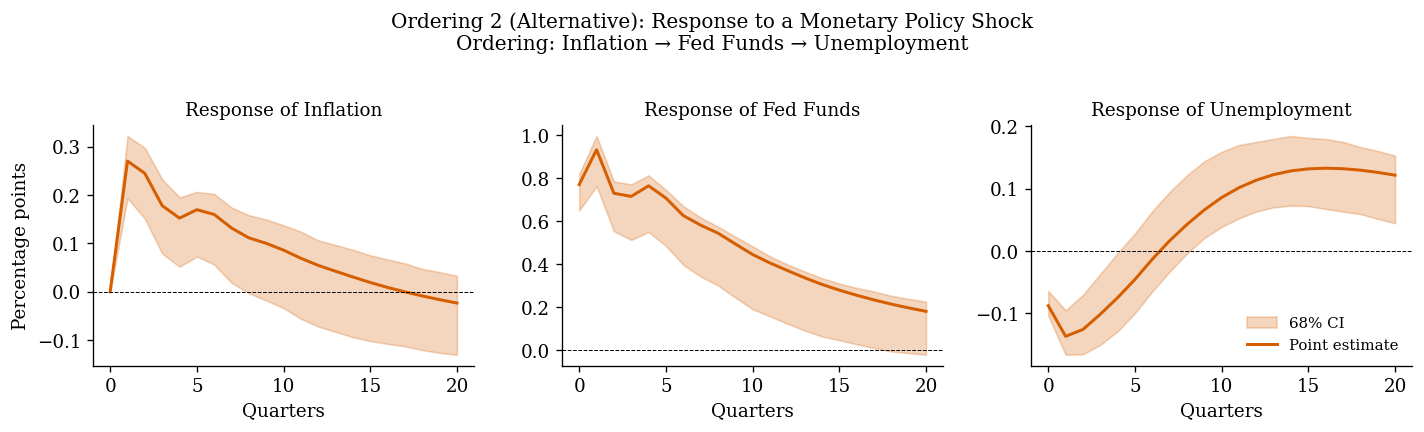

In [16]:
fig = plot_irf(
    irf_alt, irf_lo_alt, irf_hi_alt,
    var_names=names_alt,
    shock_name='Fed Funds',
    n_ahead=N_AHEAD,
    title='Ordering 2 (Alternative): Response to a Monetary Policy Shock\n'
          'Ordering: Inflation → Fed Funds → Unemployment',
    color='#D55E00'
)
fig.savefig('fig3_irf_alt_ordering.pdf', bbox_inches='tight')
plt.show()



## 7. Comparison: Response of Inflation and Unemployment across orderings

Side-by-side comparison of the inflation and unemployment responses to the monetary policy shock under the two identification schemes.

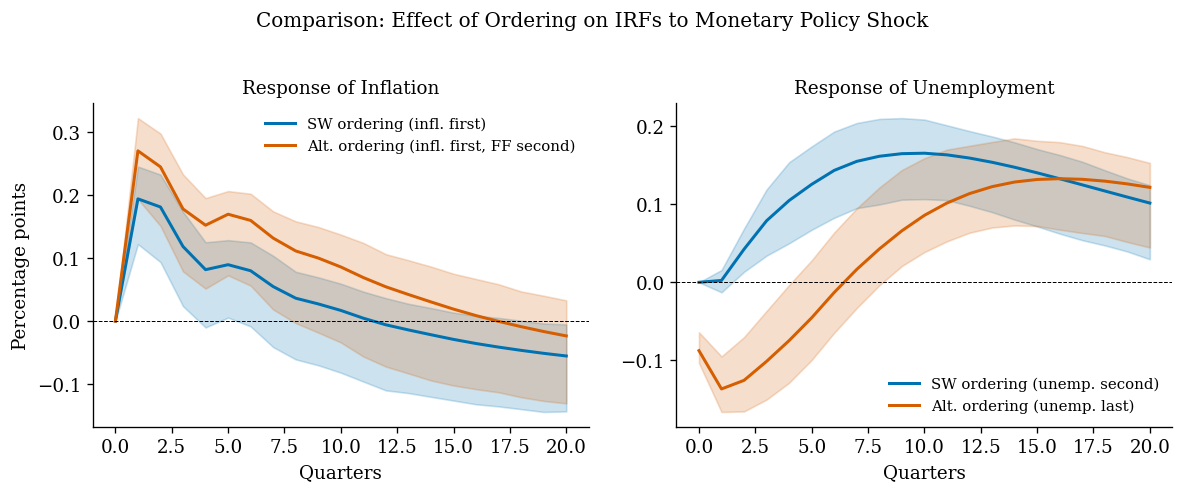

In [18]:
periods = np.arange(N_AHEAD + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Inflation response ────────────────────────────────────────────────────
ax = axes[0]
# SW ordering: inflation is variable 0
ax.fill_between(periods, irf_lo_sw[:, 0], irf_hi_sw[:, 0],
                alpha=0.2, color='#0072B2')
ax.plot(periods, irf_sw[:, 0], color='#0072B2', lw=1.8,
        label='SW ordering (infl. first)')
# Alt ordering: inflation is variable 0
ax.fill_between(periods, irf_lo_alt[:, 0], irf_hi_alt[:, 0],
                alpha=0.2, color='#D55E00')
ax.plot(periods, irf_alt[:, 0], color='#D55E00', lw=1.8,
        label='Alt. ordering (infl. first, FF second)')
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.set_title('Response of Inflation', fontsize=11)
ax.set_xlabel('Quarters')
ax.set_ylabel('Percentage points')
ax.legend(fontsize=9, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Unemployment response ─────────────────────────────────────────────────
ax = axes[1]
# SW ordering: unemployment is variable 1
ax.fill_between(periods, irf_lo_sw[:, 1], irf_hi_sw[:, 1],
                alpha=0.2, color='#0072B2')
ax.plot(periods, irf_sw[:, 1], color='#0072B2', lw=1.8,
        label='SW ordering (unemp. second)')
# Alt ordering: unemployment is variable 2
ax.fill_between(periods, irf_lo_alt[:, 2], irf_hi_alt[:, 2],
                alpha=0.2, color='#D55E00')
ax.plot(periods, irf_alt[:, 2], color='#D55E00', lw=1.8,
        label='Alt. ordering (unemp. last)')
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.set_title('Response of Unemployment', fontsize=11)
ax.set_xlabel('Quarters')
ax.legend(fontsize=9, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Comparison: Effect of Ordering on IRFs to Monetary Policy Shock',
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig('fig4_irf_comparison.pdf', bbox_inches='tight')
plt.show()

## Notes

**Data:**
- Inflation: $400 \times \ln(P_t/P_{t-1})$ where $P_t$ is the GDP deflator (FRED: `GDPDEF`).
- Unemployment: quarterly average of monthly UNRATE.
- Fed Funds: quarterly average of monthly FEDFUNDS.

**VAR:** 4 lags, constant included, OLS equation-by-equation.

**Identification:** Recursive (Cholesky) decomposition of the reduced-form residual covariance matrix $\Sigma_u = PP'$. The monetary policy shock is the structural shock to the Fed Funds equation. The ordering determines the contemporaneous restrictions:
- In the SW ordering, monetary policy cannot affect inflation or unemployment within the same quarter.
- In the alternative ordering, monetary policy cannot affect inflation within the quarter but can affect unemployment.

**Bootstrap bands:** Residual bootstrap with 500 replications, 68% confidence intervals (approximately one standard deviation, standard in the SVAR literature).